# EFA example

In this example, we perform the Evolving Factor Analysis


sphinx_gallery_thumbnail_number = 2


In [1]:
import os

import spectrochempy as scp

"<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAABgAAAAYCAYAAADgdz34AAAAAXNSR0IArs4c6QAAAAlw SFlzAAAJOgAACToB8GSSSgAAAetpVFh0WE1MOmNvbS5hZG9iZS54bXAAAAAAADx4OnhtcG1ldGEgeG1sbnM6eD0iYWRvYmU6bnM6 bWV0YS8iIHg6eG1wdGs9IlhNUCBDb3JlIDUuNC4wIj4KICAgPHJkZjpSREYgeG1sbnM6cmRmPSJodHRwOi8vd3d3LnczLm9yZy8x OTk5LzAyLzIyLXJkZi1zeW50YXgtbnMjIj4KICAgICAgPHJkZjpEZXNjcmlwdGlvbiByZGY6YWJvdXQ9IiIKICAgICAgICAgICAg eG1sbnM6eG1wPSJodHRwOi8vbnMuYWRvYmUuY29tL3hhcC8xLjAvIgogICAgICAgICAgICB4bWxuczp0aWZmPSJodHRwOi8vbnMu YWRvYmUuY29tL3RpZmYvMS4wLyI+CiAgICAgICAgIDx4bXA6Q3JlYXRvclRvb2w+bWF0cGxvdGxpYiB2ZXJzaW9uIDIuMS4wLCBo dHRwOi8vbWF0cGxvdGxpYi5vcmcvPC94bXA6Q3JlYXRvclRvb2w+CiAgICAgICAgIDx0aWZmOk9yaWVudGF0aW9uPjE8L3RpZmY6 T3JpZW50YXRpb24+CiAgICAgIDwvcmRmOkRlc2NyaXB0aW9uPgogICA8L3JkZjpSREY+CjwveDp4bXBtZXRhPgqNQaNYAAAGiUlE QVRIDY1We4xU1Rn/3XPuYx47u8w+hnU38hTcuoUEt/6D2y4RB0ME1BoEd9taJaKh9CFiN7YGp7appUAMNmktMZFoJTYVLVQ0smsy 26CN0SU1QgsuFAaW3WVmx33N677O6XfuyoIxTXqSO/fec+75fd93vt/3/UbDV0aKSZmCpkFMLz3T9utuu2N+o98aDSMBKVAo89z5 y+zEz3ZafcCOfvWdlGCalqKn1Bf71CygTd+mf1esSOnpdMpTb+vWpTZuWVfe3jLPa5tzHYNm0T5N0gpdkkHaDBeGBU6d1/t/fyS8 +/CbqdfUvmsx1PuMgc2bNxv79u1zgd31r+7JH1jbIZKxWRXAcYUQ8IWvBfBXNjEuJWPgMA02NR7C3/pYT9fjdZ3A9tGrWF8YSJHn qcDz3y7q2T967PZv+gnYJdd1mEZ+62zGDQV/dQgKhmLzDNOXCEWM3j6eTT5Y3w78dOBKJLR1PQf+4ivPj76UPZnssBN+wbM9Aet/ AV81Mf1EEULXYfOobvX2WWQk0aoioXwwSmirOlioY0mu8BIouzYl7P8GV3vpqCCEZvlFz769w08oLDWvyKIyL1asSm28d6WfzA97 ztvvV1kexUMsmhlkULEkuGYmFYC6AvfUrITnwUKl5K79lkjeSSRRTCTbQPd95e1WzMbZSya74XoXAxctCllCnbECMOjZNGRwvzIX nD85wbkMmKK+U045Dtdi8Qp+SAxU2GTg2bYlC9224pgvmSb54vkVTBQYyhUt2KjAMyMmPjwRQW5Mh2WKwJhlBh6jVGagFM84wZnQ 4bpC0Rt4pk1PbSt0NDcxDA5xryosDHWgtbM0DGZDWLSoiDMDYeQnGVrmOThxLozB0RAaahzkJzjKNqcIQBymJFMkOlN8Dqjpg0XY Tx5xO/QbmmUrqIjGJznq47TqTaClKYfjp+PInLMwnOdYvtQBZ2XcunQY+VwIo4U4muoFEjVEFE6lQyEUKzHYfgQG9ylCyngU+Cxj tOqxCDGHcCsOMCs6iQul5ZiStdATYxjMZXDLTUVwLY8Jey4uOh2IxjwsrP8UXJYxUrkZrghBahzV5iXU6gNkq0Z1EzIsUBUSCV2n EOHo0LVxHCpuxabJJdhi5PFnvw5vLXwXIfNZvD/+JNo/X40NegE54sUaazl+UL8XD1x+FB9Ijjt4EQfdGN6J/x131LwIV9ap/AYs 0x1fz1ZKFbh6A7qKy/By9Dg6G36Ep91vUJJ15Cqr0Z67E8/HzmBrw1OwxWyM+3Mo6BAuSB17oyfx0Oyl2DN0Hqs/70Cx6hBCvESF UY1ShWXZZEE7OTAYxZzaPH4TuoiusZvRnunFy2NbiHYuBp2vB66srX4vMEjpRKPxKXmnoQ4+Mn4DPiv8CYcrs3GfNUXJLtM+alSO hrMj/KT+wBNW3+E/2liywNO3iSflbaFva/+stGDTxE0E9Sjaox8HBhxpEamzMGSEaFKg+mjEddzDh1MxTDq3YV1kGBsjfwW3S9Cq anjmko+ndlb1UR3s6K8JlfphNWq9Ew/7c61T2BB/EbcaNkb8GBaE0tANH7/M34PLdhJDzjIcL9xPbdTG6zyM72Y+wXPHmvB489No fm0b5HnbQ9Rgp/7DSSd29AeVvPeNyK6JcYl/yQVi5dBjuGvoV/gaJe47s45QUxrDmcYX0MBsdF7egvXZ7+O0vZA4X8QmOQWjlSK7 RDz5wIM30gp9UbWcGjXxhzdDu1SiNSpx6kcQB57rPnr/3dlkZarWLnlRq5oPET1dOCIOk4wALib9eeS5iygfhkd09H0DWphB/+gs +PcOAS+ssrFmmXXgVfR0de9cpbAJfH3Q1jofW9DZk56dDcVsq9YcsoUMEd1qyLoT3BX1YiyHMJuk97hyjqIoE91t+NcTLeN0ZrfM oXatZbu6G0h4VG+ibqq0IJVK6cAjo6serG3vSUezCMct0yQeSOFJSUImqb2qbknUpDqlZxE0QZ+ZUpSlZx79h4Nda6zef9dlk121 JDjbR5XggPRZlRnS6bRQRtLpn4++cuie/Yvn2svmNxuLw9WCcYIl4fEoTEGiSTUqJdfgU+8ROqf1iMkLzS389YtNPXc/PH8l8ONB JZkHD+4JtD04HmVEDWWErmBhzV2/2LB1bemJG6krzv2S6NOHUgtEP0Oif5pE/3fHoruP7N8RiP61GArzSwbUhJJQpXJKiKbfr/3b IhKq76sKPUdF9NW/LSqfSn6vjv8C45H/6FSgvZQAAAAASUVORK5CYII=' style='height:25px; border-radius:12px; display:inline-block; float:left; vertical-align:middle'>",SpectroChemPy's API - v.0.6.11.dev5© Copyright 2014-2025 - A.Travert & C.Fernandez @ LCS


Upload and preprocess a dataset


In [2]:
datadir = scp.preferences.datadir
dataset = scp.read_omnic(os.path.join(datadir, "irdata", "nh4y-activation.spg"))

Change the time origin


In [3]:
dataset.y -= dataset.y[0]

columns masking


In [4]:
dataset[:, 1230.0:920.0] = scp.MASKED  # do not forget to use float in slicing
dataset[:, 5997.0:5993.0] = scp.MASKED

difference spectra dataset -= dataset\[-1\]


<_Axes: title={'center': 'NH4_Y activation dataset'}, xlabel='wavenumbers $\\mathrm{/\\ \\mathrm{cm}^{-1}}$', ylabel='absorbance $\\mathrm{/\\ \\mathrm{a.u.}}$'>

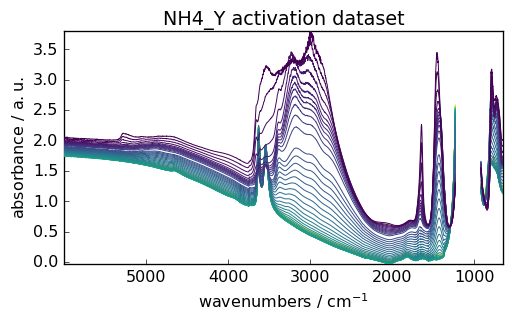

In [5]:
dataset.plot_stack(title="NH4_Y activation dataset")

Evolving Factor Analysis


In [6]:
efa1 = scp.EFA()
_ = efa1.fit(dataset)

Forward evolution of the 5 first components


<_Axes: xlabel='acquisition timestamp (GMT) $\\mathrm{/\\ \\mathrm{s}}$', ylabel='absorbance $\\mathrm{}$'>

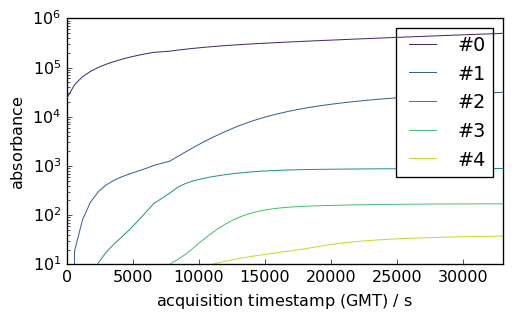

In [7]:
f = efa1.f_ev[:, :5]
f.T.plot(yscale="log", legend=f.k.labels)

Note the use of coordinate \'k\' (component axis) in the expression
above. Remember taht to find the actul names of the coordinates, the
[dims]{.title-ref} attribute can be used as in the following:


<_Axes: xlabel='acquisition timestamp (GMT) $\\mathrm{/\\ \\mathrm{s}}$', ylabel='absorbance $\\mathrm{}$'>

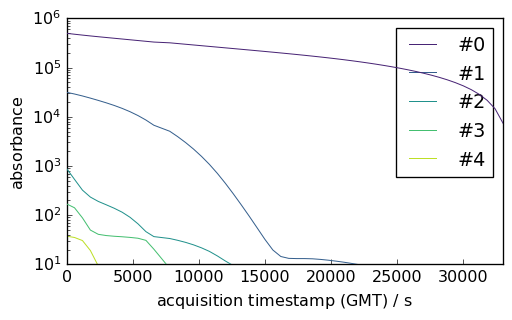

In [8]:
f.dims

# Backward evolution
b = efa1.b_ev[:, :5]
b.T[:5].plot(yscale="log", legend=b.k.labels)

Show results with 3 components (which seems to already explain a large
part of the dataset) we use the magnitude of the 4th component for the
cut-off value (assuming it corresponds mostly to noise)


<_Axes: title={'center': 'EFA determined concentrations'}, xlabel='acquisition timestamp (GMT) $\\mathrm{/\\ \\mathrm{s}}$', ylabel='values $\\mathrm{}$'>

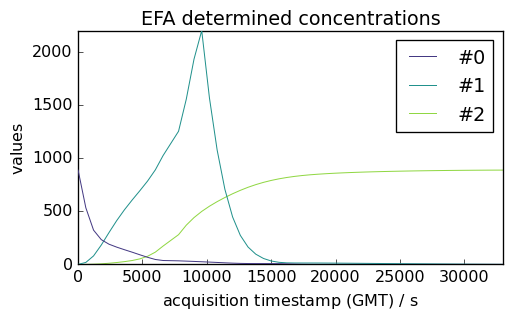

In [9]:
efa1.n_components = 3
efa1.cutoff = efa1.f_ev[:, 3].max()

# get concentration
C1 = efa1.transform()
C1.T.plot(title="EFA determined concentrations", legend=C1.k.labels)

Fit transform : Get the concentration in too commands The number of
desired components can be passed to the EFA model, followed by the
fit_transform method:


In [10]:
efa2 = scp.EFA(n_components=3)
C2 = efa2.fit_transform(dataset)
assert C1 == C2

Get components


<_Axes: title={'center': 'components'}, xlabel='wavenumbers $\\mathrm{/\\ \\mathrm{cm}^{-1}}$', ylabel='values $\\mathrm{}$'>

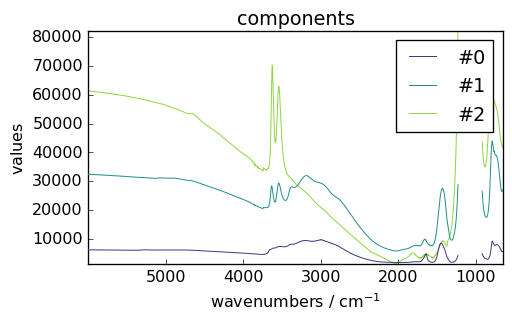

In [11]:
St = efa2.get_components()
St.plot(title="components", legend=St.k.labels)

Compare with PCA


In [12]:
pca = scp.PCA(n_components=3)
C3 = pca.fit_transform(dataset)

<_Axes: title={'center': 'PCA scores'}, xlabel='acquisition timestamp (GMT) $\\mathrm{/\\ \\mathrm{s}}$', ylabel='values $\\mathrm{}$'>

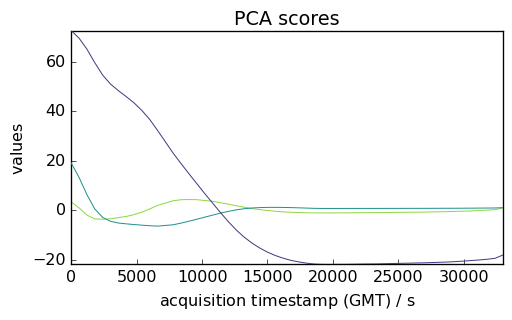

In [13]:
C3.T.plot(title="PCA scores")

<_Axes: title={'center': 'PCA components'}, xlabel='wavenumbers $\\mathrm{/\\ \\mathrm{cm}^{-1}}$', ylabel='values $\\mathrm{}$'>

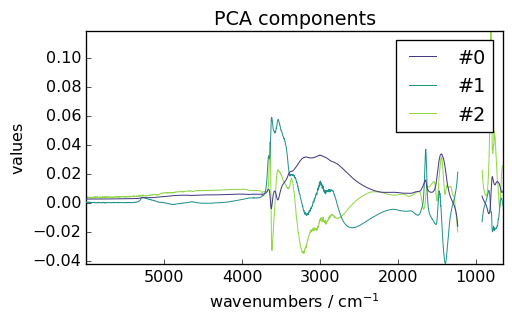

In [14]:
LT = pca.loadings
LT.plot(title="PCA components", legend=LT.k.labels)

This ends the example ! The following line can be uncommented if no plot
shows when running the .py script with python


In [15]:
# scp.show()